In [2]:
import pandas as pd

df = pd.read_csv(r"C:\Users\user\Downloads\OIBSIP\train.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [3]:
print("Rows and Columns:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Rows and Columns: (9800, 18)

Column Names:
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

Data Types:
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object

Missing Values:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City  

In [4]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [5]:
print("Mean:")
print(df.mean(numeric_only=True))

print("\nMedian:")
print(df.median(numeric_only=True))

print("\nMode:")
print(df.mode(numeric_only=True).iloc[0])

print("\nStandard Deviation:")
print(df.std(numeric_only=True))

Mean:
Row ID          4900.500000
Postal Code    55273.322403
Sales            230.769059
dtype: float64

Median:
Row ID          4900.50
Postal Code    58103.00
Sales             54.49
dtype: float64

Mode:
Row ID             1.00
Postal Code    10035.00
Sales             12.96
Name: 0, dtype: float64

Standard Deviation:
Row ID          2829.160653
Postal Code    32041.223413
Sales            626.651875
dtype: float64


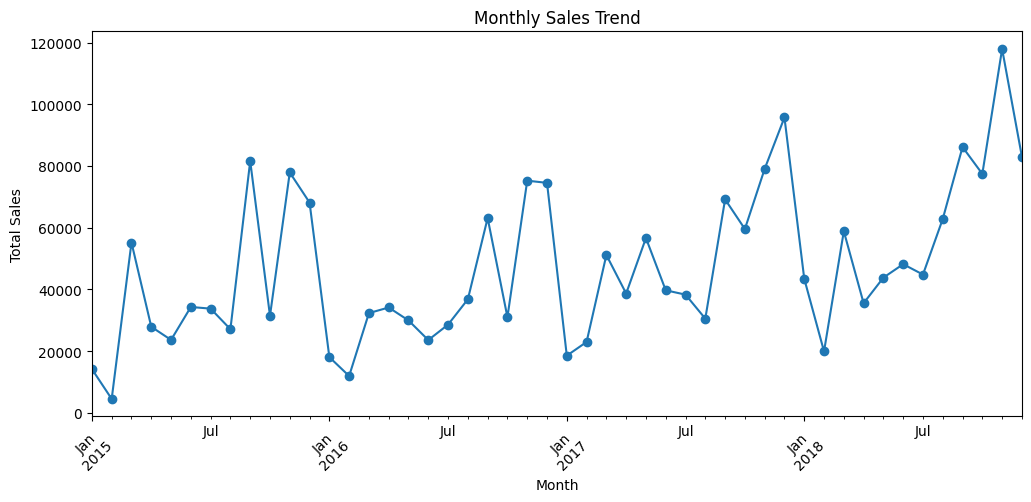

In [7]:
import matplotlib.pyplot as plt

df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

monthly_sales = df.groupby(
    df['Order Date'].dt.to_period('M')
)['Sales'].sum()

monthly_sales.plot(
    kind='line',
    figsize=(12, 5),
    marker='o'
)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

### Observation – Monthly Sales Trend

The monthly sales trend shows how sales changed over time. The sales pattern fluctuates across different months, indicating variations in customer demand and purchasing activity.

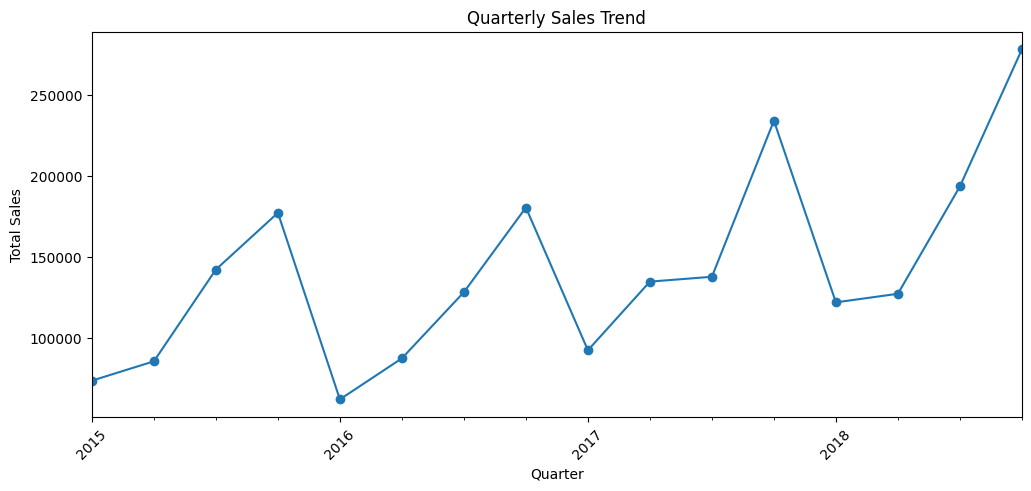

In [17]:
quarterly_sales = df.groupby(
    df['Order Date'].dt.to_period('Q')
)['Sales'].sum()

quarterly_sales.plot(
    kind='line',
    figsize=(12, 5),
    marker='o'
)

plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

### Observation – Quarterly Sales Trend

The quarterly sales trend shows changes in total sales across different quarters. The fluctuations indicate that sales performance varies over time and may reflect seasonal changes in customer demand.

In [10]:
print(df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']


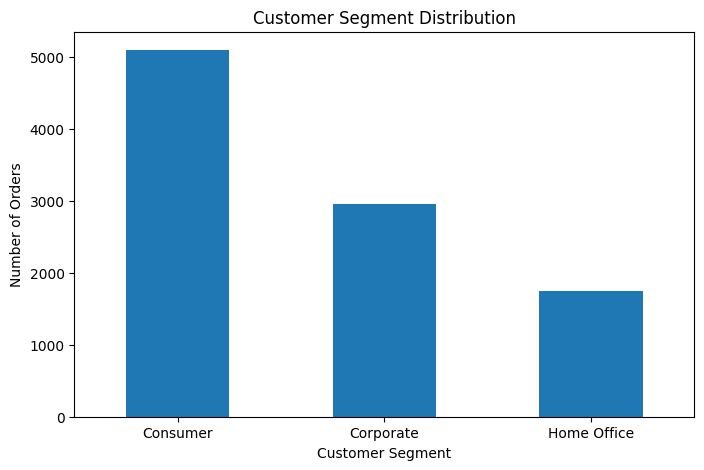

In [11]:
segment_counts = df['Segment'].value_counts()

segment_counts.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Customer Segment Distribution')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.show()

### Observation – Customer Segment Distribution

The customer segment distribution shows the number of orders from different customer segments. The results indicate differences in purchasing activity across the segments.

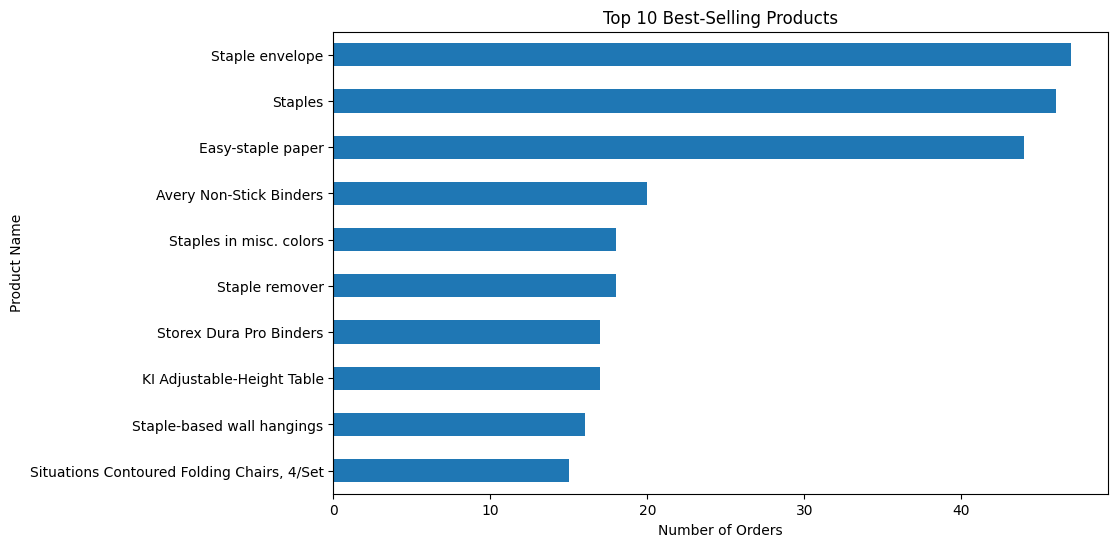

In [12]:
top_10_products = df['Product Name'].value_counts().head(10)

top_10_products.plot(
    kind='barh',
    figsize=(10, 6)
)

plt.title('Top 10 Best-Selling Products')
plt.xlabel('Number of Orders')
plt.ylabel('Product Name')
plt.gca().invert_yaxis()
plt.show()

### Observation – Top 10 Best-Selling Products

The top 10 products show which products have the highest number of orders. This helps identify products with strong customer demand and can support inventory and sales planning.

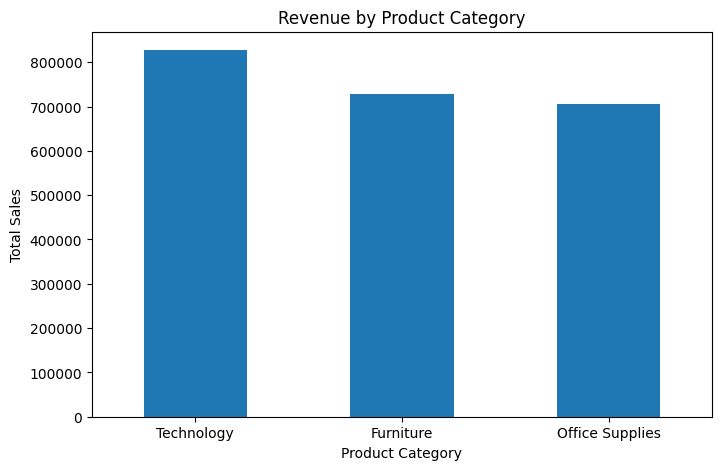

In [13]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

category_sales.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.show()

### Observation – Revenue by Product Category

The revenue by product category shows differences in total sales across the categories. This helps identify which product categories contribute more to overall revenue and can support category-level sales planning.

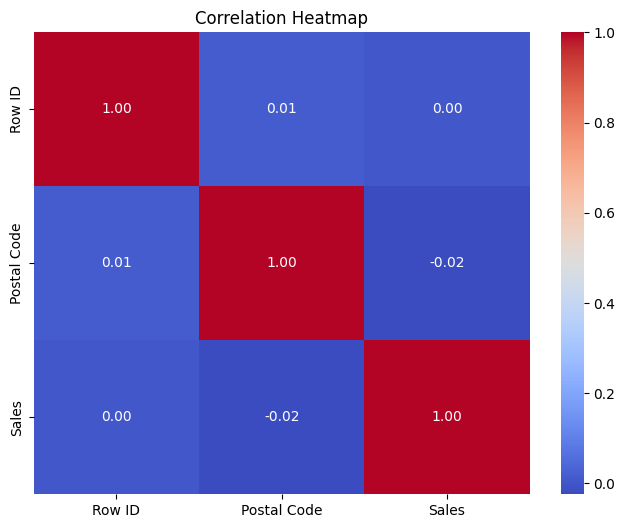

In [14]:
import seaborn as sns

numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(8, 6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

### Observation – Correlation Heatmap

The correlation heatmap shows the relationships between the numerical variables in the dataset. It helps identify variables that have stronger or weaker relationships with each other.

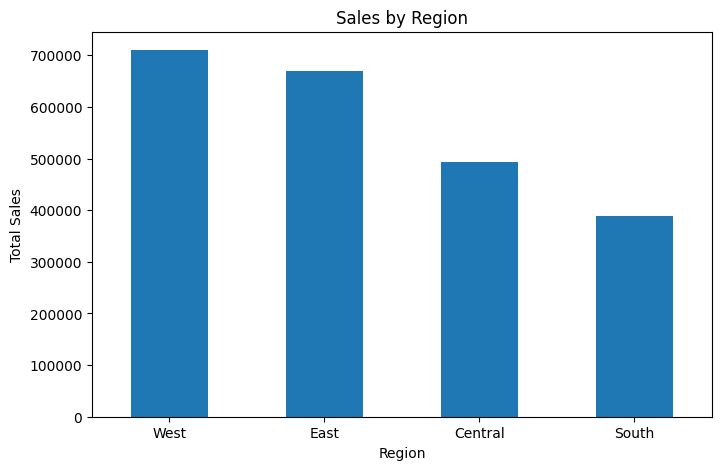

In [15]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

region_sales.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.show()

### Observation – Sales by Region

The sales by region visualization shows differences in total sales across regions. This helps identify regional variations in sales performance and can support regional sales planning.

## Conclusion

The exploratory data analysis provided useful insights into sales trends, customer segments, product performance, product categories, and regional sales.

### Actionable Business Recommendations

1. Focus on high-demand products and maintain sufficient inventory to avoid stock shortages.

2. Strengthen sales strategies for product categories and regions that contribute more to overall revenue.

3. Use monthly and quarterly sales trends to improve sales forecasting, inventory planning, and promotional strategies.